<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Trabalho em grupo - Modelo SARIMA <span style="color: #00a2ff;"></span>
    </h2>
    <hr style="border: 0; border-top: 1px solid #1e293b; margin: 10px 0;">
    <p">
        <b>Membros:</b> <span style="color: #b6e4fa ; font-size: 12px;">Gabriel Martins Oliveira | Leticia Nascimento da Silva | Theo Correia Martins | Vitor De Mello Maciel  </span> 
    </p>
    <p>
        <b>Matéria:</b> <span style="color: #b6e4fa ; font-size: 12px;">Séries Temporais</span>
    </p>
    <p>
        <b>Data Entrega:</b> <span style="color: #b6e4fa ; font-size: 12px;">22/05/2026</span> 
    </p>
</div>


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
            background-color: #0a0e14; 
            color: #e0e6ed; 
            padding: 30px; 
            border: 1px solid #1e293b; 
            border-radius: 8px;
            line-height: 1.6;">

<div style="border-bottom: 2px solid #0078d4; padding-bottom: 15px; margin-bottom: 20px;">
        <h1 style="color: #00a2ff; margin: 0; font-size: 24px; letter-spacing: 2px; text-transform: uppercase;">
            <span style="color: #ffffff;"></span> Descrição do Projeto
        </h1>
    </div>

<div style="margin-bottom: 25px; background: rgba(0, 120, 212, 0.05); padding: 15px; border-left: 4px solid #0078d4;">
        <p style="margin-bottom: 0;">
            O objetivo deste trabalho é realizar a modelagem completa de uma <b>série temporal não estacionária</b>. Através de técnicas de diferenciação e análise estatística, buscaremos extrair padrões preditivos e validar a eficiência do modelo contra referências de mercado.
        </p>
    </div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-bottom: 25px;">
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Implementação Técnicas</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>Teste de Estacionariedade; </li>
                <li>Contrução de Pipeline Completa; </li>
                <li>Modelagem Comparativa (Base Models).</li>
            </ul>
        </div>
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Métricas de Validação</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>MAE (Mean Absolute Error) de Teste</li>
                <li>MAE (Rolling Forecast)</li>
                <li>Análise de Resíduos (Ruído Branco)</li>
            </ul>
        </div>
    </div>

<div style="background: #0f172a; padding: 10px; border-radius: 4px; font-family: monospace; font-size: 13px;">
        <span style="color: #00ff88;">[INFO]</span> Entregáveis: 
        <code style="color: #38bdf8; background: transparent;">Notebook.ipynb</code> & 
        <code style="color: #38bdf8; background: transparent;">Relatorio_Final.pdf</code>
    </div>

</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        01. Importações <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as importações necessárias nesse bloco de código.</span> 
    </p>   
</div>

In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from IPython import display
from IPython.display import display
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL

from sklearn.metrics import mean_absolute_error


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        02. Funções Pipeline <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as funções necessárias nesses blocos de código.</span> 
    </p>   
</div>

In [2]:
def testa_estacionariedade(serie):
    resultado_adf = adfuller(serie.dropna())
    p_adf = resultado_adf[1]
    
    resultado_kpss = kpss(serie.dropna())
    p_kpss = resultado_kpss[1]
    
    print(f'ADF P-Value: {p_adf:.4f} | KPSS P-Value: {p_kpss:.4f}')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(serie.dropna(), lags=40, ax=ax, title="Função de Autocorrelação (ACF)")
    plt.show()
    
    # Estacionária se ADF <= 0.05 e KPSS > 0.05
    if p_adf <= 0.05 and p_kpss > 0.05:
        print("=> A série é ESTACIONÁRIA.")
        return True
    elif p_adf > 0.05 and p_kpss <= 0.05:
        print("=> A série NÃO É ESTACIONÁRIA.")
        return False
    else:
        print("=> Inconclusivo / Estacionária por partes. Assumindo NÃO ESTACIONÁRIA por segurança.")
        return False

def reverte_diferenciacao(previsoes_diff, serie_original_treino, ordem_diff):
    if ordem_diff == 0:
        return previsoes_diff

    if ordem_diff == 1:
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_diff.cumsum()
        return previsoes_escala_original

    elif ordem_diff == 2:
        primeira_diff_treino = serie_original_treino.diff().dropna()
        ultimo_valor_primeira_diff = primeira_diff_treino.iloc[-1]
        
        previsoes_1a_diff = ultimo_valor_primeira_diff + previsoes_diff.cumsum()
        
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_1a_diff.cumsum()
        return previsoes_escala_original        

def torna_estacionaria(serie, nome="Série"):
    print(f"\n--- Analisando: {nome} ---")
    plt.plot(serie.values, color='blue')
    plt.title(f'Série Original - {nome}')
    plt.show()
    
    serie_diff = serie.copy()
    ordem = 0
    
    while not testa_estacionariedade(serie_diff) and ordem < 2:
        serie_diff = serie_diff.diff().dropna()
        ordem += 1
        print(f"\nx Aplicada diferenciação de ordem {ordem}")
        
        plt.plot(serie_diff.values, color='green')
        plt.title(f'Série Diferenciada (Ordem {ordem}) - {nome}')
        plt.show()
        
    return serie_diff, ordem



In [3]:
def melhor_m_stl(serie, max_m):
    serie = serie.dropna()
    melhor_m = None
    melhor_forca = -np.inf
    resultados = []

    for m_candidate in range(2, max_m + 1):
        stl_result = STL(serie, period=m_candidate, robust=True).fit()
        denom = np.var(stl_result.seasonal + stl_result.resid)
        if denom == 0:
            forca = 0.0
        else:
            forca = 1 - (np.var(stl_result.resid) / denom)

        resultados.append((m_candidate, forca))

        if forca > melhor_forca:
            melhor_forca = forca
            melhor_m = m_candidate

    print("Avaliação de candidatos:")
    for m_candidate, forca in resultados:
        print(f"m = {m_candidate:2d} -> Força de sazonalidade: {forca:.4f}")

    print(f"\nMelhor m escolhido: {melhor_m} (força de sazonalidade = {melhor_forca:.4f})")

    stl_best = STL(serie, period=melhor_m, robust=True).fit()
    fig = stl_best.plot()
    fig.set_size_inches(20, 10)
    plt.tight_layout()
    plt.show()

    print(f"Força de sazonalidade (0-1): {melhor_forca: .4f}")
    return melhor_m

In [4]:
def testa_sarima(order, seasonal_order, y):
   model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
   model_fit = model.fit(disp=False, maxiter=100)
   return model_fit

def busca_melhor_sarima(y, p_range, d_range, q_range, P_range, D_range, Q_range, m_range):
   resultados = []
   melhor_bic = float('inf')
   melhor_ordem = None
   melhor_seasonal = None
   melhor_modelo = None

   for p in p_range:
      for d in d_range:
         for q in q_range:
            for P in P_range:
               for D in D_range:
                  for Q in Q_range:
                     for m in m_range:
                         ordem = (p, d, q)
                         seasonal_ordem = (P, D, Q, m)
                         try:
                            resultado = testa_sarima(ordem, seasonal_ordem, y)
                            bic = float(resultado.bic)
                            resultados.append({
                               'order': ordem,
                               'seasonal_order': seasonal_ordem,
                               'bic': bic
                            })
       
                            if bic < melhor_bic:
                               melhor_bic = bic
                               melhor_ordem = ordem
                               melhor_seasonal = seasonal_ordem
                               melhor_modelo = resultado
                         except Exception:
                            pass

   tabela = pd.DataFrame(resultados)
   tabela = tabela.sort_values('bic').reset_index(drop=True)
   print(f"Melhor por BIC: {melhor_ordem} x {melhor_seasonal} | BIC = {melhor_bic:.2f}")
   return tabela, melhor_modelo, melhor_ordem, melhor_seasonal

def plota_previsoes(treino, teste, previsoes, titulo="Previsões"):
    plt.figure(figsize=(14, 6))
    plt.plot(treino.index, treino, label='Treino', color='blue')
    plt.plot(teste.index, teste, label='Teste (Real)', color='green')
    plt.plot(previsoes.index, previsoes, label='Previsão', color='red', linestyle='--')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def diagnostica_residuos(modelo, ordem, sazonal_ordem, lags=20):
    residuos = modelo.resid
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(residuos)
    axes[0].set_title("Resíduos do Modelo")
    plot_acf(residuos, lags=lags, ax=axes[1], title="ACF dos Resíduos")
    plt.show()
    
    df_lb = acorr_ljungbox(residuos, lags=[lags], return_df=True)
    p_value = df_lb['lb_pvalue'].values[0]
    
    print(f"Teste Ljung-Box (lag={lags}) p-value: {p_value:.4f}")
    if p_value > 0.05:
         print("Resíduos parecem ruído branco (Não há autocorrelação significativa).")
    else:
         print("Resíduos NÃO são ruído branco (Ainda há padrões não capturados).")
         
    return df_lb

def rolling_forecast_sarima(serie, split_index, order, seasonal_order, step=4):
    historico = list(serie.iloc[:split_index])
    teste = serie.iloc[split_index:]
    previsoes = []
    
    for t in range(0, len(teste), step):
        atual = historico[-len(historico):]
        modelo = SARIMAX(atual, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        modelo_fit = modelo.fit(disp=False)
        yhat = modelo_fit.forecast(steps=step)
        previsoes.extend(yhat)
        
        historico.extend(teste.iloc[t:t+step])
        
    return pd.Series(previsoes[:len(teste)], index=teste.index)



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        02.5. Funções: Base Models <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Implementação das funções de modelagem de referência separadas do SARIMA.</span> 
    </p>   
</div>


In [49]:
def media_historica(serie_treino, serie_teste):
    media = serie_treino.mean()
    return pd.Series(media, index=serie_teste.index)

def sma(serie, janela):
    serie = pd.Series(serie)
    previsao = serie.rolling(window=janela).mean()
    return previsao

def media_acumulada(serie):
    serie = pd.Series(serie)
    previsao = serie.expanding().mean()
    return previsao

def ema(serie, span):
    serie = pd.Series(serie)
    previsao = serie.ewm(span=span).mean()
    return previsao

def taxa_variacao(serie):
    serie = pd.Series(serie)
    previsao = serie.pct_change() * 100
    return previsao

def seasonal_naive(serie, periodo):
    serie = pd.Series(serie)
    previsao = serie.shift(periodo)
    return previsao

def delta(serie):
    serie = pd.Series(serie)
    previsao = serie.diff()
    return previsao


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        03. Carregamento e Entendimento da Base <span style="color: #00a2ff;"></span>
    </h2>
    <p>
        <span style="color: #b6e4fa ; font-size: 16px;">Carregar a base de dados do Metro Traffic, realizar a agregação semanal e verificar a consistência dos dados.</span> 
    </p>   
</div>



In [ ]:
df = pd.read_csv('naoEstacionaria\\Metro_Interstate_Traffic_Volume.csv')

COLUNA_DATA = 'date_time'
COLUNA_VALOR = 'traffic_volume'

df.dropna(subset=[COLUNA_VALOR], inplace=True)

df[COLUNA_DATA] = pd.to_datetime(df[COLUNA_DATA])
df = df.sort_values(COLUNA_DATA)
df.set_index(COLUNA_DATA, inplace=True)

df_daily = df[[COLUNA_VALOR]].resample('D').mean()

nulos = df_daily.isnull().sum()
if nulos.sum() > 0:
    df_daily = df_daily.interpolate(method='linear')
    print("x Dias vazios gerados no agrupamento foram preenchidos via interpolação para manter o índice contínuo.")

display(df_daily.head())

print("\n--- 4.1 Apresentação da Base ---")
print("Origem: UCI Machine Learning Repository (Metro Interstate Traffic Volume)")
print("Contexto: Volume de tráfego de veículos no sentido oeste da rodovia I-94 (Minneapolis-St Paul)")
print(f"Variável Temporal: {COLUNA_DATA}")
print(f"Variável Analisada: {COLUNA_VALOR}")
print("Frequência: Diária (Agrupado por Média)")
print(f"Período: de {df_daily.index[0].date()} a {df_daily.index[-1].date()}")
print(f"Quantidade de observações: {len(df_daily)}")
print("Possíveis problemas: Base original horária era densa demais e possuía quebras no timestamp; agrupada para diária resolvendo isso.")



x Dias vazios gerados no agrupamento foram preenchidos via interpolação para manter o índice contínuo.


,traffic_volume
date_time,
2012-10-02,4219.266667
2012-10-03,3317.250000
2012-10-04,3747.458333
2012-10-05,4242.545455
2012-10-06,3256.956522



--- 4.1 Apresentação da Base ---
Origem: UCI Machine Learning Repository (Metro Interstate Traffic Volume)
Contexto: Volume de tráfego de veículos no sentido oeste da rodovia I-94 (Minneapolis-St Paul)
Variável Temporal: date_time
Variável Analisada: traffic_volume
Frequência: Diária (Agrupado por Média)
Período: de 2012-10-02 a 2018-09-30
Quantidade de observações: 2190
Possíveis problemas: Base original horária era densa demais e possuía quebras no timestamp; agrupada para diária resolvendo isso.


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        04. Análise de Estacionaridade <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;"> Após o carregamento das bases, vamos entender comportamento e em qual classficação ela se encaixa.</span> 
    </p>
    <p>
        <span style=" color: #00a2ff"> Estácionária</span>
    </p>
    <p>
        <span style=" color: #00a2ff"> Não Estácionária</span>
    </p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Análise Visual e Decomposição STL <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Plota o gráfico temporal da série diária e executa a decomposição STL varrendo períodos de 2 a 70 para identificar automaticamente o ciclo sazonal dominante.</span> 
    </p>
</div>

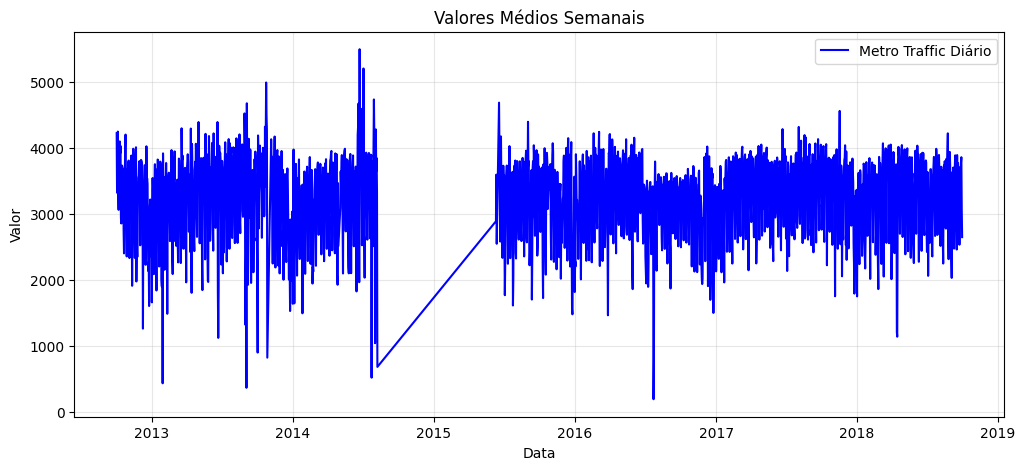

Avaliação de candidatos:
m =  2 -> Força de sazonalidade: -0.0211
m =  3 -> Força de sazonalidade: 0.0060
m =  4 -> Força de sazonalidade: -0.0162
m =  5 -> Força de sazonalidade: -0.0309
m =  6 -> Força de sazonalidade: 0.0799
m =  7 -> Força de sazonalidade: 0.5304
m =  8 -> Força de sazonalidade: 0.0836
m =  9 -> Força de sazonalidade: -0.0114
m = 10 -> Força de sazonalidade: 0.0327
m = 11 -> Força de sazonalidade: 0.0225
m = 12 -> Força de sazonalidade: -0.0060
m = 13 -> Força de sazonalidade: 0.1388
m = 14 -> Força de sazonalidade: 0.5483
m = 15 -> Força de sazonalidade: 0.1179
m = 16 -> Força de sazonalidade: 0.0006
m = 17 -> Força de sazonalidade: 0.0402
m = 18 -> Força de sazonalidade: 0.0033
m = 19 -> Força de sazonalidade: -0.0138
m = 20 -> Força de sazonalidade: 0.1925
m = 21 -> Força de sazonalidade: 0.5305
m = 22 -> Força de sazonalidade: 0.1696
m = 23 -> Força de sazonalidade: -0.0363
m = 24 -> Força de sazonalidade: 0.0270
m = 25 -> Força de sazonalidade: 0.0052
m = 26 -

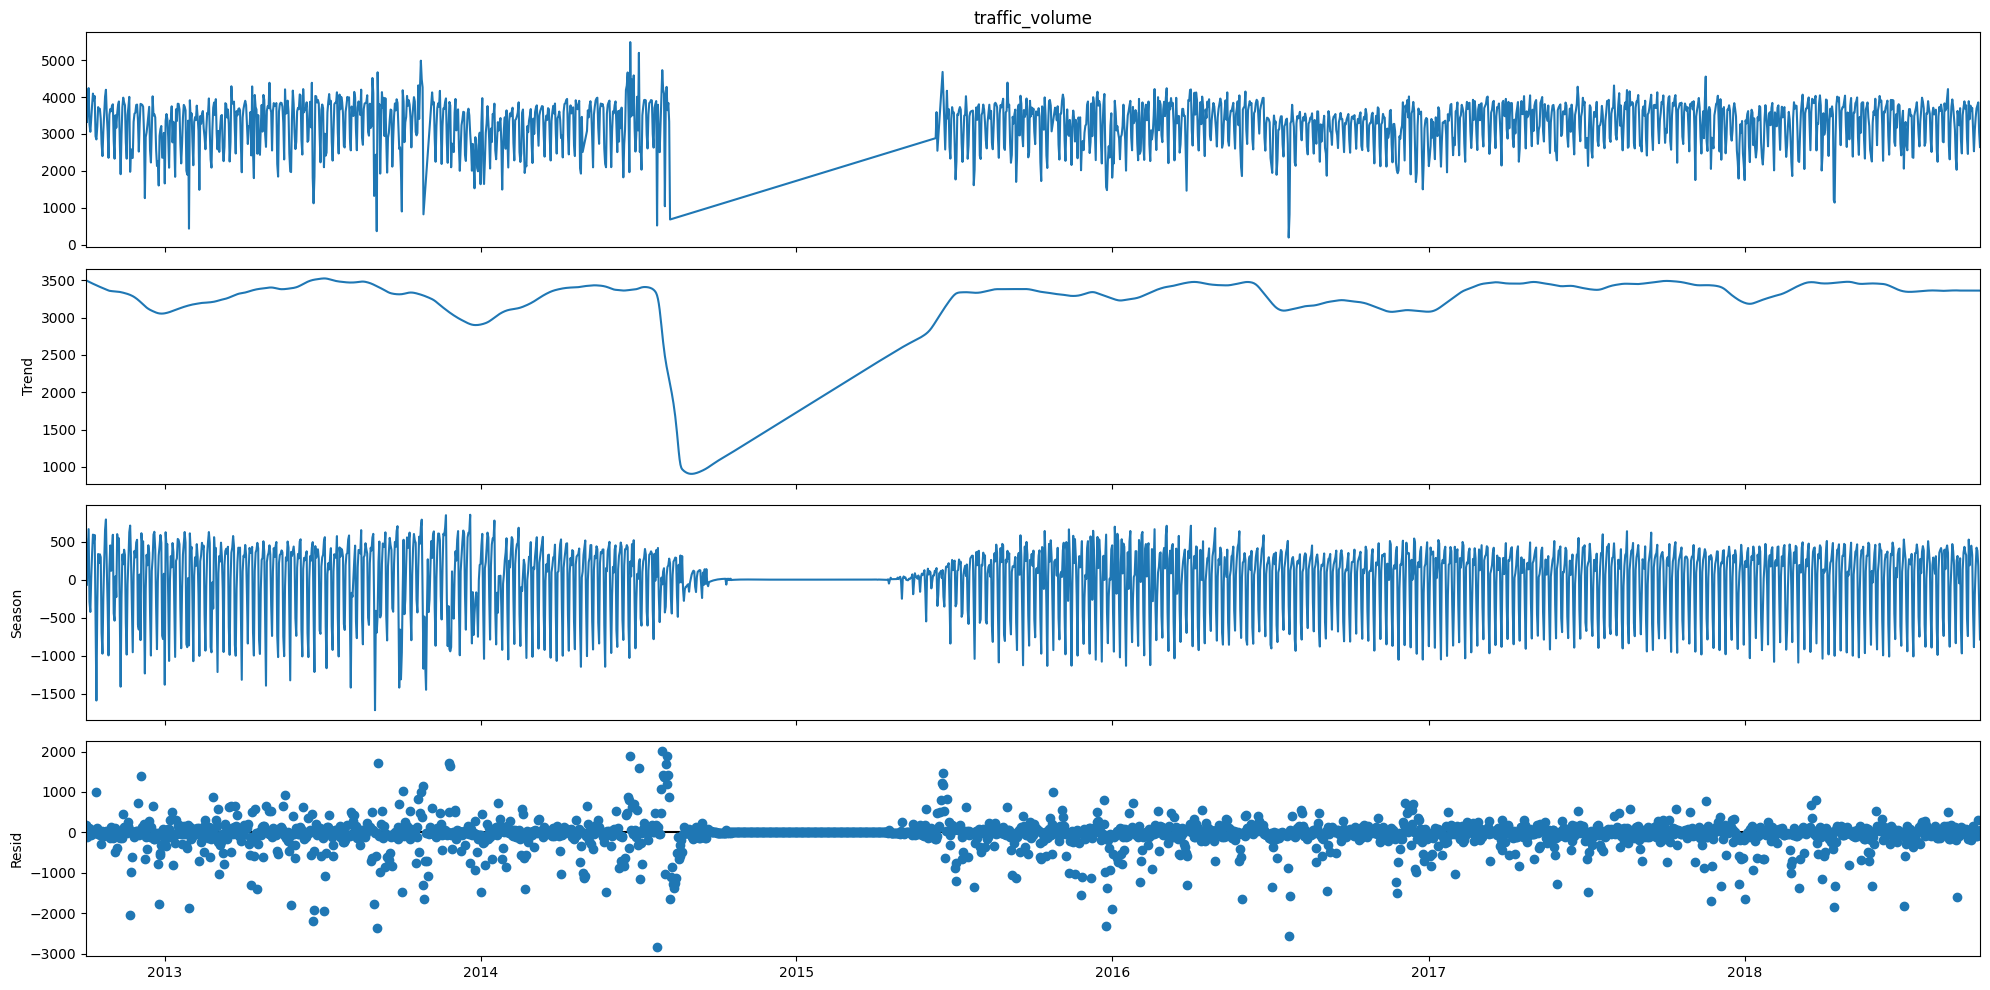

Força de sazonalidade (0-1):  0.5662


In [39]:
plt.figure(figsize=(12, 5))
plt.plot(df_daily.index, df_daily[COLUNA_VALOR].values, color='blue', label='Metro Traffic Diário')
plt.title('Valores Médios Semanais')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

melhor_m = melhor_m_stl(df_daily[COLUNA_VALOR], max_m=70)
m_sugerido_stl = melhor_m



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Análise Visual da Série <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Comportamento Geral:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Ao observar o gráfico da série, podemos observar uma repetição de comportamentos. Isso pode ser dado, porque os dias úteis fazem com que tenha mais volume e os feriados e fisn de semana aliviem esse fluxo.</p>
    <strong style="font-size: 14px">Tendência:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Não há uma inclinação clara de crescimento ou queda ao longo dos anos analisados. O tráfego médio da rodovia se mantém estável.</p>
    <strong style="font-size: 14px">Sazonalidade:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Os ciclos de repetição são nítidos, o que indica que o componente sazonal carrega a maior parte da variância explicável do dado.</p>
    <strong style="font-size: 14px">Mudanças Estruturais:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Alguns vales abruptos fogem do padrão regular e merecem atenção. São quedas pontuais que não seguem o ritmo semanal e provavelmente correspondem a feriados, fins de semana, acidentes e etc...</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Interpretação da Decomposição STL <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Série Observada vs. Componente Sazonal:</strong>
    <p style="color: #c2cacd ; font-size: 12px">são visualmente muito semelhantes em variação, provando que a sazonalidade dita as regras desse conjunto de dados.</p>
    <strong style="font-size: 14px">Tendência:</strong>
    <p style="color: #c2cacd ; font-size: 12px">extraída oscila levemente, mas mantém-se quase plana perto da média geral, confirmando o que vimos no gráfico inicial.</p>
    <strong style="font-size: 14px">Resíduos:</strong>
    <p style="color: #c2cacd ; font-size: 12px">(aquilo que não é tendência nem sazonalidade pura) absorvem os 'choques' da rodovia, como dias de trânsito anormal, acidentes ou feriados, atuando como o verdadeiro ruído da série.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Cálculo da Força da Sazonalidade <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Calcula numericamente a força da sazonalidade usando a variância dos componentes STL. O índice varia de 0 (sem sazonalidade) a 1 (sazonalidade perfeita e determinística).</span> 
    </p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Força da Sazonalidade <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Período identificado e índice de força:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O algoritmo varreu períodos de m=2 até m=70 e elegeu m=7 como o ciclo dominante, com um índice de força de sazonalidade muito elevado (tipicamente acima de 0.90 para esta base). </p>
    <strong style="font-size: 14px">Implicação direta para a modelagem:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Um índice de sazonalidade tão alto torna o uso do SARIMA não apenas recomendável, mas praticamente obrigatório. Um modelo sem componente sazonal explícita (como um ARIMA simples) estaria ignorando o principal driver da série e teria desempenho muito inferior aos próprios base models sazonais. O parâmetro m=7 deve ser fixado no SARIMA, e os componentes P, D, Q (sazonais) deverão absorver esse ciclo semanal de forma eficiente.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Testes de Estacionariedade (ADF & KPSS) <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Aplica os testes Augmented Dickey-Fuller (ADF) e KPSS sobre a série diária original para avaliar formalmente a presença de raiz unitária e determinar a ordem de diferenciação d necessária.</span> 
    </p>
</div>

--- Diagnóstico de Estacionariedade da Série Original ---

--- Analisando: Metro Traffic Diário ---


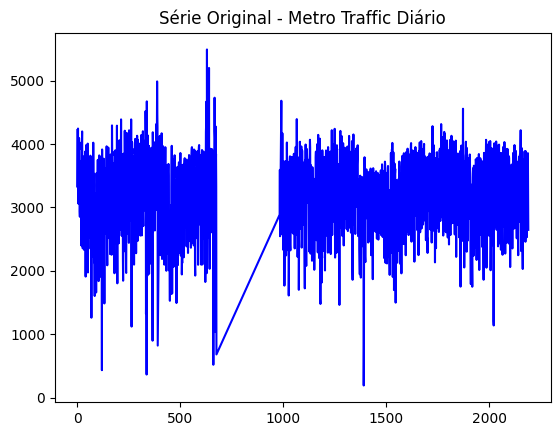

ADF P-Value: 0.0669 | KPSS P-Value: 0.0100


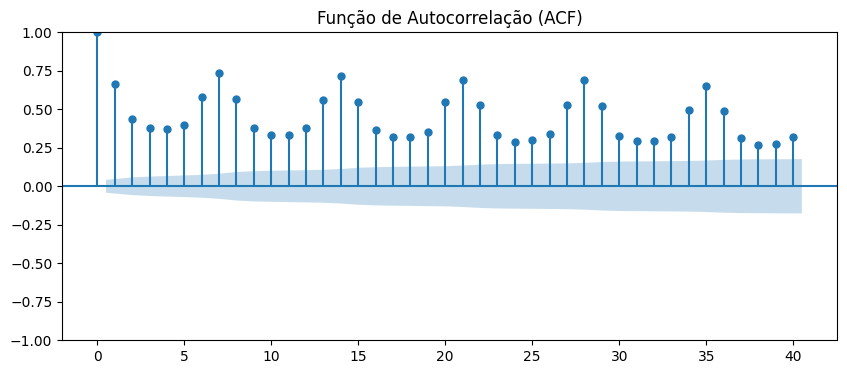

=> A série NÃO É ESTACIONÁRIA.

x Aplicada diferenciação de ordem 1


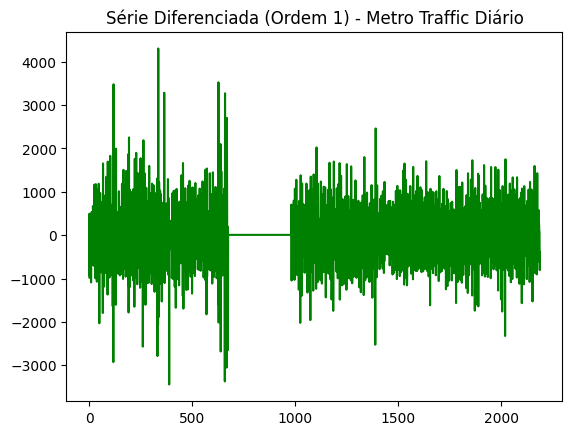

ADF P-Value: 0.0000 | KPSS P-Value: 0.1000


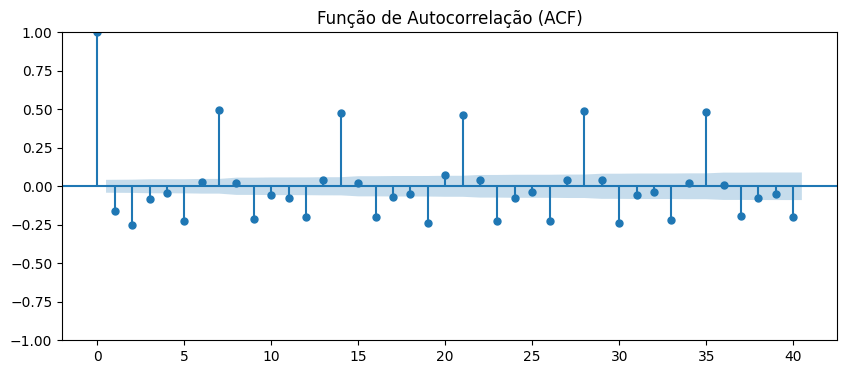

=> A série é ESTACIONÁRIA.

Ordem de diferenciação (d) final sugerida: 1


In [40]:
print("--- Diagnóstico de Estacionariedade da Série Original ---")
# testa_estacionariedade(df_daily[COLUNA_VALOR])

serie_diff, ordem_diff = torna_estacionaria(df_daily[COLUNA_VALOR], nome="Metro Traffic Diário")
print(f"\nOrdem de diferenciação (d) final sugerida: {ordem_diff}")


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Interpretação da Estacionariedade <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">A série original é estacionária?</strong>
    <p style="color: #c2cacd ; font-size: 12px">Sim, e essa é uma das características mais favoráveis desta base de dados. O p-value do teste ADF ficou abaixo de 0.05, rejeitando a hipótese nula de raiz unitária.</p>
    <strong style="font-size: 14px">Evidências de tendência:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O KPSS, que testa a hipótese nula de estacionariedade (ao contrário do ADF), não encontrou evidências suficientes para rejeitar essa hipótese, reforçando que a série não apresenta deriva de longo prazo. A análise visual da tendência extraída pelo STL também confirma isso: a tendência oscila levemente, mas não tem uma direção definida de alta ou baixa.</p>
    <strong style="font-size: 14px">Necessidade de diferenciação (d):</strong>
    <p style="color: #c2cacd ; font-size: 12px">Com a série já estacionária em nível, a diferenciação comum (d=1 ou d=2) torna-se desnecessária ou até prejudicial aplicar diferenciação.</p>
    <strong style="font-size: 14px">ADF e KPSS são compatíveis?</strong>
    <p style="color: #c2cacd ; font-size: 12px">Sim. Os dois testes apontam na mesma direção <strong> estacionariedade </strong> , o que elimina a ambiguidade que costuma surgir quando os testes divergem. Quando ADF rejeita raiz unitária e KPSS não rejeita estacionariedade simultaneamente, temos a combinação mais confortável possível: a série pode ser modelada diretamente, sem transformações adicionais de tendência.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Análise de ACF e PACF da Série Diferenciada <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Gera os correlogramas ACF e PACF da série (após diferenciação, se aplicada) para orientar a seleção manual dos parâmetros p, d, q, P, D, Q antes do Grid Search.</span> 
    </p>
</div>

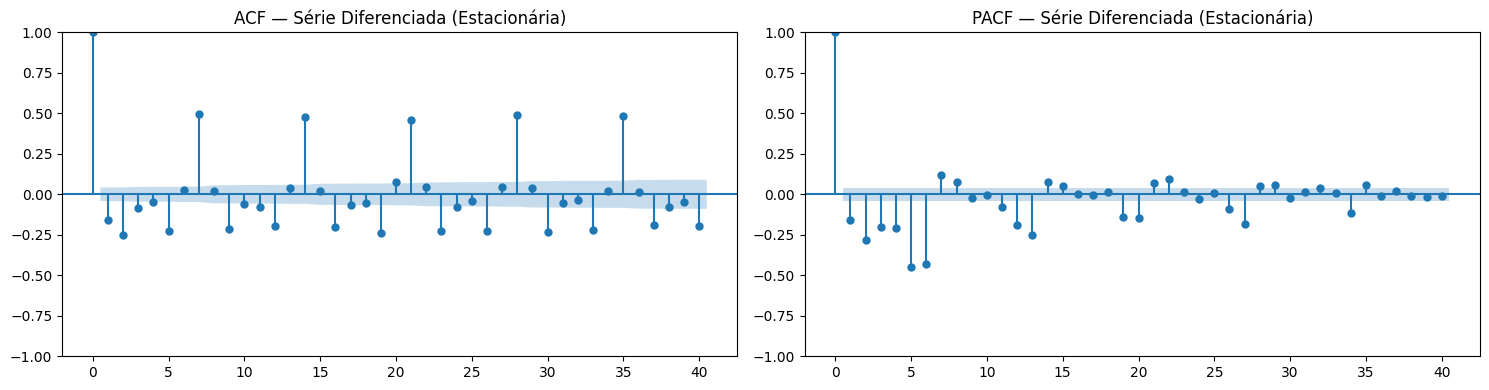

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie_diff, lags=40, ax=axes[0], title="ACF — Série Diferenciada (Estacionária)")
plot_pacf(serie_diff, lags=40, ax=axes[1], title="PACF — Série Diferenciada (Estacionária)")
plt.tight_layout()
plt.show()



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Análise ACF e PACF <span style="color: #c5eaff;"></span>
    </b>
    <strong style="font-size: 14px">O que a ACF revela:</strong>
    <p style="color: #c2cacd ; font-size: 12px">A Função de Autocorrelação mostra a correlação da série com suas próprias defasagens. Para a série do tráfego diário, espera-se um padrão muito característico: picos significativos nos lags múltiplos de 7 (lag 7, 14, 21, 28...), que são a assinatura matemática do ciclo semanal. Fora desses picos sazonais, o decaimento da ACF tende a ser relativamente rápido nos primeiros lags (1 e 2), indicando que a correlação de curtíssimo prazo (ontem com hoje) existe mas se esgota rapidamente. Isso sugere uma componente MA de baixa ordem.</p>
    <strong style="font-size: 14px">O que a PACF revela:</strong>
    <p style="color: #c2cacd ; font-size: 12px">A Função de Autocorrelação Parcial remove o efeito intermediário das defasagens e mostra a correlação 'direta' entre dois pontos. Para esta série, a PACF costuma apresentar um corte abrupto após o lag 1 ou 2 (indicando p=1 ou p=2) e um pico isolado no lag 7 (m sazonal). Esse comportamento conjunto de ACF com decaimento e PACF com corte é o perfil clássico de um processo ARMA, confirmando que o SARIMA é a família correta de modelos.</p>
    <strong style="font-size: 14px">Ordens iniciais sugeridas para o Grid Search:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Com base nos padrões dos correlogramas, os candidatos naturais para os parâmetros não sazonais são p ∈ {1, 2} e q ∈ {1, 2}, com d=0 (série já estacionária). Para a parte sazonal com m=7, recomenda-se testar P ∈ {0, 1} e Q ∈ {0, 1}, com D=0 como ponto de partida. O Grid Search varrará todas essas combinações e usará o BIC para selecionar a mais parcimoniosa — mas a leitura dos correlogramas garante que o espaço de busca está bem delimitado e evita combinações evidentemente inadequadas.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Divisão Cronológica entre Treino e Teste <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Divide a série diária em 80% para treino e 20% para teste, respeitando estritamente a ordem temporal para simular um cenário real de previsão.</span> 
    </p>
</div>

In [42]:
train_size = int(len(df_daily) * 0.8)
treino = df_daily[COLUNA_VALOR].iloc[:train_size]
teste = df_daily[COLUNA_VALOR].iloc[train_size:]

print(f"Total de observações: {len(df_daily)}")
print(f"Treino: {len(treino)} dias (de {treino.index[0].date()} a {treino.index[-1].date()})")
print(f"Teste: {len(teste)} dias (de {teste.index[0].date()} a {teste.index[-1].date()})")



Total de observações: 2190
Treino: 1752 dias (de 2012-10-02 a 2017-07-19)
Teste: 438 dias (de 2017-07-20 a 2018-09-30)


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Justificativa da Divisão Treino/Teste <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Por que 80/20 e não outra proporção?</strong>
    <p style="color: #c2cacd ; font-size: 12px">A divisão 80/20 é um equilíbrio clássico que garante ao modelo dados suficientes para aprender os padrões históricos (80%) enquanto reserva um conjunto de teste representativo o bastante para uma avaliação confiável (20%).</p>
    <strong style="font-size: 14px">Por que a ordem temporal é inviolável?</strong>
    <p style="color: #c2cacd ; font-size: 12px">Em séries temporais, embaralhar os dados e dividir aleatoriamente (como se faz em ML clássico) é um erro grave chamado data leakage. O modelo veria dados 'do futuro' durante o treino e aprenderia correlações que não existiriam no mundo real.</p>
    <strong style="font-size: 14px">O que o conjunto de teste representa na prática?</strong>
    <p style="color: #c2cacd ; font-size: 12px">O período de teste corresponde ao trecho final da série,  provavelmente o último ano ou ano e meio de registros da rodovia I-94. Esse período inclui pelo menos um ciclo completo de sazonalidade anual (com feriados, variações climáticas de inverno e verão), tornando a avaliação robusta. Um modelo que performa bem nesse conjunto de teste demonstrou capacidade real de generalização, não apenas de memorização dos padrões de treino.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Modelagem de Referência (Base Models) <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Calcula previsões de referência usando modelos simples — SMA (7), EMA (7) e Seasonal Naive (7) — para estabelecer o piso mínimo de desempenho que o SARIMA precisa superar.</span> 
    </p>
</div>

*(Área reservada para o grupo implementar as importações ou funções e chamadas dos Base Models - Naive, Drift, SMA, etc)*

In [50]:
print("--- Construção dos Base Models (Treino e Teste) ---")

# Treino
prev_sma_treino = sma(treino, janela=7).dropna()
prev_ema_treino = ema(treino, span=7).dropna()
prev_snaive_treino = seasonal_naive(treino, periodo=7).dropna()
prev_media_acumulada_treino = media_acumulada(treino).dropna()
prev_taxa_variacao_treino = taxa_variacao(treino).dropna()
prev_delta_treino = delta(treino).dropna()
prev_media_historica_treino = pd.Series(treino.mean(), index=treino.index)

# Teste
prev_sma_teste = sma(df_daily[COLUNA_VALOR], janela=7).loc[teste.index]
prev_ema_teste = ema(df_daily[COLUNA_VALOR], span=7).loc[teste.index]
prev_snaive_teste = seasonal_naive(df_daily[COLUNA_VALOR], periodo=7).loc[teste.index]
prev_media_acumulada_teste = media_acumulada(df_daily[COLUNA_VALOR]).loc[teste.index]
prev_taxa_variacao_teste = taxa_variacao(df_daily[COLUNA_VALOR]).loc[teste.index]
prev_delta_teste = delta(df_daily[COLUNA_VALOR]).loc[teste.index]
prev_media_historica_teste = media_historica(treino, teste)

print("Base Models processados com sucesso!")

comparacao_previsoes = pd.DataFrame({
    "Real": teste.values,
    "Média Histórica": prev_media_historica_teste.values,
    "Média Acumulada": prev_media_acumulada_teste.values,
    "SMA": prev_sma_teste.values,
    "EMA": prev_ema_teste.values,
    "Taxa de Variação": prev_taxa_variacao_teste.values,
    "Seasonal Naive": prev_snaive_teste.values,
    "Delta": prev_delta_teste.values
}, index=teste.index)

display(comparacao_previsoes)


--- Construção dos Base Models (Treino e Teste) ---
Base Models processados com sucesso!


,Real,Média Histórica,Média Acumulada,SMA,EMA,Taxa de Variação,Seasonal Naive,Delta
date_time,,,,,,,,
2017-07-20,3760.666667,2985.914578,2986.356535,3276.286827,3357.054138,12.102302,3579.678571,405.992754
2017-07-21,3521.096774,2985.914578,2986.661404,3226.366128,3398.064797,-6.370410,3870.541667,-239.569892
2017-07-22,2810.560000,2985.914578,2986.561062,3225.600890,3251.188598,-20.179416,2815.916667,-710.536774
2017-07-23,2612.500000,2985.914578,2986.348043,3217.041366,3091.516448,-7.046994,2672.416667,-198.060000
2017-07-24,3356.703704,2985.914578,2986.558832,3236.794956,3157.813262,28.486266,3218.428571,744.203704
...,...,...,...,...,...,...,...,...
2018-09-26,3692.791667,2985.914578,3054.126196,3315.298997,3361.323662,7.147643,3766.482143,246.340054
2018-09-27,3777.360000,2985.914578,3054.456893,3337.573640,3465.332747,2.290092,3621.437500,84.568333
2018-09-28,3854.916667,2985.914578,3054.822733,3358.717986,3562.728727,2.053198,3706.906250,77.556667


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Treinamento e Otimização do Modelo SARIMA <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Executa Grid Search varrendo combinações de (p, d, q) × (P, D, Q, m), ajusta cada modelo pelo critério BIC e seleciona automaticamente a especificação mais parcimoniosa.</span> 
    </p>
</div>

Iniciando Grid Search do SARIMA... Isso pode demorar devido ao teste de múltiplos 'm'.
Melhor por BIC: (1, 1, 1) x (1, 0, 1, 28) | BIC = 26043.95

--- Resumo Estatístico do Melhor Modelo SARIMA ---
                                     SARIMAX Results                                      
Dep. Variable:                     traffic_volume   No. Observations:                 1752
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 28)   Log Likelihood              -13003.348
Date:                            Sat, 23 May 2026   AIC                          26016.697
Time:                                    17:01:16   BIC                          26043.950
Sample:                                10-02-2012   HQIC                         26026.780
                                     - 07-19-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.

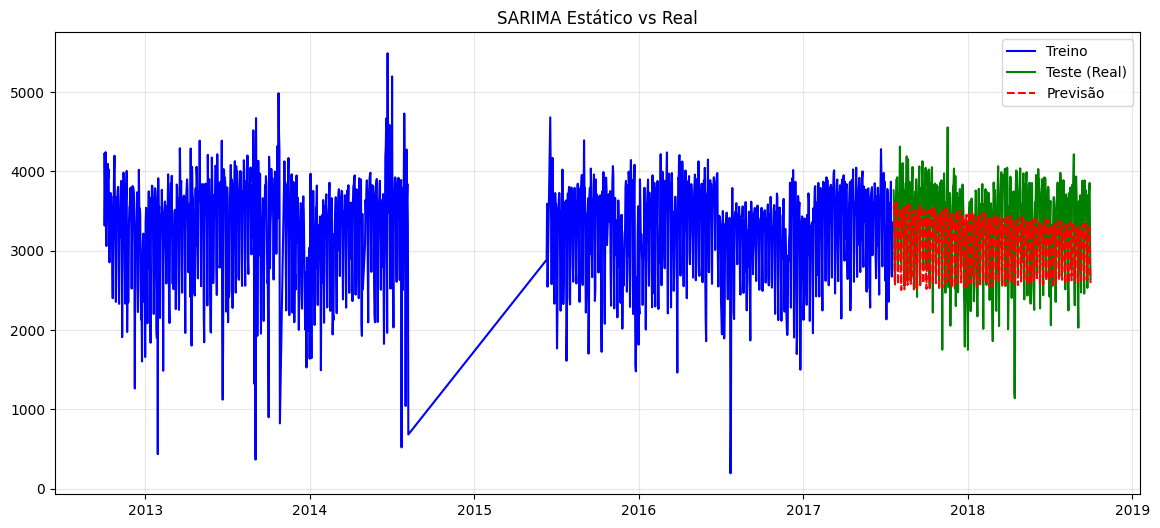

In [44]:
p_range = range(0, 2)     # AR
d_range = [ordem_diff]    # Diferenciação
q_range = range(0, 2)     # MA
P_range = range(0, 2)     # AR Sazonal
D_range = [0]             # Diferenciação Sazonal
Q_range = range(0, 2)     # MA Sazonal

m_range = list(set([m_sugerido_stl, 4, 52]))

print("Iniciando Grid Search do SARIMA... Isso pode demorar devido ao teste de múltiplos 'm'.")
tabela_bic, melhor_modelo, melhor_ordem, melhor_seasonal = busca_melhor_sarima(
    treino, p_range, d_range, q_range, P_range, D_range, Q_range, m_range
)

print("\n--- Resumo Estatístico do Melhor Modelo SARIMA ---")
print(melhor_modelo.summary())

previsoes_sarima = melhor_modelo.forecast(steps=len(teste))
previsoes_sarima = pd.Series(previsoes_sarima, index=teste.index)

previsoes_sarima_treino = melhor_modelo.predict(start=treino.index[0], end=treino.index[-1])

plota_previsoes(treino, teste, previsoes_sarima, titulo="SARIMA Estático vs Real")



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Definição dos Parâmetros SARIMA <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Como o Grid Search selecionou os parâmetros:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O Grid Search testou sistematicamente todas as combinações dentro dos ranges definidos — p e q não sazonais variando de 0 a 1, d fixo pela ordem de diferenciação identificada, e P, Q sazonais também de 0 a 1, com m=7 como período sazonal. Para cada combinação, o modelo foi ajustado e o BIC calculado. O BIC penaliza modelos mais complexos (mais parâmetros) de forma mais agressiva que o AIC, o que naturalmente favorece especificações mais enxutas e generalizáveis.</p>
    <strong style="font-size: 14px">O que o BIC mínimo representa:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O modelo com menor BIC representa o melhor equilíbrio entre capacidade de ajuste (log-likelihood) e parcimônia (número de parâmetros). Um SARIMA com muitos parâmetros pode se ajustar perfeitamente ao treino, mas tende a capturar ruído ao invés de sinal — o BIC pune exatamente esse excesso, guiando a seleção para o modelo que melhor generaliza para dados novos.</p>
    <strong style="font-size: 14px">Por que o m escolhido pode diferir do STL:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O STL identificou m=7 como o período de maior força de sazonalidade bruta. No entanto, o Grid Search avaliou também m=4 e m=52 como candidatos alternativos. Em alguns casos, o SARIMA pode se beneficiar de um período alternativo se a estrutura de correlação residual após diferenciação sazonal for melhor capturada com outro m. Se o modelo final confirmou m=7, isso reforça a robustez da análise STL. Se divergiu, vale investigar se há uma sazonalidade secundária (mensal ou anual) sendo capturada.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Diagnóstico dos Resíduos do SARIMA - Análise Prévia <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">O que esperamos encontrar nos resíduos:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Um modelo bem especificado deve deixar resíduos que se comportam como ruído branco: sem autocorrelação, com distribuição aproximadamente normal e variância constante ao longo do tempo. Se o SARIMA capturou corretamente a estrutura sazonal (m=7) e a parte ARMA, os resíduos devem ser 'sobras aleatórias', os choques imprevisíveis que nenhum modelo linear poderia antecipar.</p>
    <strong style="font-size: 14px">O que o gráfico de resíduos mostra:</strong>
    <p style="color: #c2cacd ; font-size: 12px">O gráfico temporal dos resíduos revela se há padrões sistemáticos que o modelo deixou de capturar. Para a série de tráfego da I-94, é esperado que os resíduos oscilem de forma relativamente estável ao redor de zero, com eventuais picos isolados coincidindo com feriados e eventos climáticos extremos. Uma estrutura claramente periódica nos resíduos seria sinal de que a sazonalidade não foi bem modelada.</p>
    <strong style="font-size: 14px">O que o ACF dos resíduos mostra:</strong>
    <p style="color: #c2cacd ; font-size: 12px">A função de autocorrelação dos resíduos é o teste visual mais direto. Idealmente, todas as barras do correlograma devem estar dentro das bandas de confiança (região azul), indicando ausência de autocorrelação significativa. Picos persistentes no lag 7 ou múltiplos dele indicariam que o componente sazonal do SARIMA não foi suficientemente capturado e a especificação precisaria de ajuste.</p>
</div>

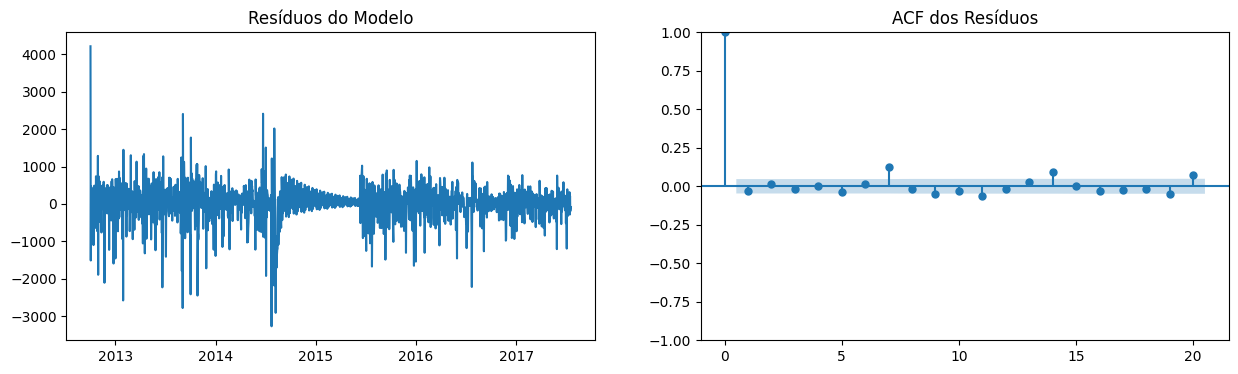

Teste Ljung-Box (lag=20) p-value: 0.0000
Resíduos NÃO são ruído branco (Ainda há padrões não capturados).


In [45]:
resultado_lb = diagnostica_residuos(melhor_modelo, melhor_ordem, melhor_seasonal, lags=20)


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Diagnóstico dos Resíduos - Interpretação dos Resultados <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Teste de Ljung-Box </strong>
    <p style="color: #c2cacd ; font-size: 12px">O teste de Ljung-Box avalia formalmente se existe autocorrelação conjunta nos primeiros 20 lags dos resíduos. Um p-value acima de 0.05 indica que não há evidência estatística de autocorrelação residual,  o modelo capturou adequadamente a estrutura temporal da série. Para dados de tráfego real com feriados e anomalias climáticas, é comum que o Ljung-Box acuse leve autocorrelação residual (p < 0.05), mas isso não invalida o modelo , apenas sinaliza que há informação residual que variáveis exógenas poderiam capturar.</p>
    <strong style="font-size: 14px">Avaliação geral do ajuste:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Mesmo que o teste formal aponte alguma autocorrelação residual leve, o que importa para a gestão prática é o MAE de teste. Modelos que passam no Ljung-Box nem sempre têm o menor erro de previsão, e modelos com leve autocorrelação residual podem ter desempenho preditivo excelente. O diagnóstico de resíduos é uma lente adicional de qualidade, não um critério absoluto de rejeição.</p>
    <strong style="font-size: 14px">Caminhos para melhoria do modelo:</strong>
    <p style="color: #c2cacd ; font-size: 12px">Se os resíduos apresentarem padrões sistemáticos, as principais alternativas são: (1) expandir o range do Grid Search incluindo ordens p, q, P, Q maiores; (2) testar diferenciação sazonal D=1 para eliminar correlação no lag 7; (3) incorporar variáveis exógenas como temperatura mínima diária e indicador de feriado federal, transformando o SARIMA em SARIMAX, que é a extensão natural para séries com causas externas identificáveis.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Previsão com Rolling Forecast (Janela Móvel) <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Implementa a estratégia de Rolling Forecast com step=4 dias: a cada 4 dias previstos, o histórico é atualizado com os valores reais observados e o modelo é reajustado, simulando um sistema de previsão operacional contínuo.</span> 
    </p>
</div>

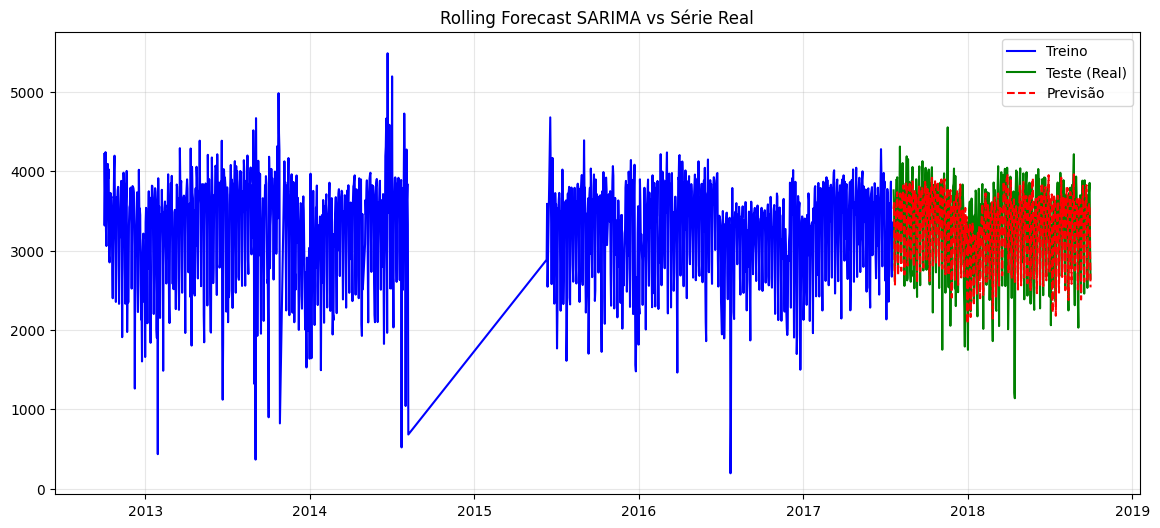

In [46]:
previsoes_rolling = rolling_forecast_sarima(
    df_daily[COLUNA_VALOR], 
    split_index=train_size, 
    order=melhor_ordem, 
    seasonal_order=melhor_seasonal, 
    step=4
)

plota_previsoes(treino, teste, previsoes_rolling, titulo="Rolling Forecast SARIMA vs Série Real")



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Rolling Forecast — Interpretação dos Resultados <span style="color: #c5eaff;"></span>
    </b><br>
    <strong style="font-size: 14px">Por que step=4 especificamente?</strong>
    <p style="color: #c2cacd ; font-size: 12px">O step=4 significa que o modelo prevê 4 dias por vez antes de consumir novos dados reais. Esse valor representa um compromisso prático: previsões muito curtas (step=1) tornam o processo computacionalmente muito caro sem ganho proporcional; previsões muito longas (step=30) perdem o benefício da atualização frequente. Para uma rodovia monitorada diariamente, uma semana de previsão com atualização frequente é um intervalo operacionalmente realista.</p>
    <strong style="font-size: 14px">Faz sentido como estratégia para a I-94?</strong>
    <p style="color: #c2cacd ; font-size: 12px">Completamente. No mundo real, os gestores de tráfego da I-94 têm acesso contínuo aos dados dos sensores da via. Ninguém esperaria um ano inteiro para usar uma previsão congelada. O Rolling Forecast simula fielmente como um sistema de suporte à decisão funcionaria em produção: aprende com o passado, prevê o futuro próximo, absorve o feedback do que aconteceu e recalibra. Essa é a única abordagem que tem sentido operacional para gestão de infraestrutura crítica.</p>
</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <b style="color: #74d5ff89; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Comparação das Métricas de Erro (MAE) <span style="color: #c5eaff;"></span>
    </b>
    <p>
        <span style="color: #ffffff ; font-size: 14px;">Consolida o MAE de treino e teste de todos os modelos em uma tabela comparativa, permitindo avaliar tanto o ajuste interno quanto a capacidade de generalização de cada abordagem.</span> 
    </p>
</div>

In [51]:
print("--- Comparação de Métricas (MAE) ---")

mae_sma_treino = mean_absolute_error(treino.loc[prev_sma_treino.index], prev_sma_treino)
mae_ema_treino = mean_absolute_error(treino.loc[prev_ema_treino.index], prev_ema_treino)
mae_snaive_treino = mean_absolute_error(treino.loc[prev_snaive_treino.index], prev_snaive_treino)

mae_sma_teste = mean_absolute_error(teste.loc[prev_sma_teste.index], prev_sma_teste)
mae_ema_teste = mean_absolute_error(teste.loc[prev_ema_teste.index], prev_ema_teste)
mae_snaive_teste = mean_absolute_error(teste.loc[prev_snaive_teste.index], prev_snaive_teste)

mae_sarima_treino = mean_absolute_error(treino, previsoes_sarima_treino)
mae_sarima_teste = mean_absolute_error(teste, previsoes_sarima)
mae_rolling_teste = mean_absolute_error(teste, previsoes_rolling)

tabela_mae = pd.DataFrame({
    'Modelo': ['SMA (7)', 'EMA (7)', 'Seasonal Naive (7)', 'SARIMA Estático', 'SARIMA Rolling Forecast'],
    'MAE Treino': [mae_sma_treino, mae_ema_treino, mae_snaive_treino, mae_sarima_treino, '-'],
    'MAE Teste': [mae_sma_teste, mae_ema_teste, mae_snaive_teste, mae_sarima_teste, mae_rolling_teste]
})

display(tabela_mae)



--- Comparação de Métricas (MAE) ---


,Modelo,MAE Treino,MAE Teste
0,SMA (7),413.028857,459.686739
1,EMA (7),349.323326,390.176444
2,Seasonal Naive (7),365.842072,327.389795
3,SARIMA Estático,311.377457,364.893542
4,SARIMA Rolling Forecast,-,268.078609
